In [66]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
f_sig = "../coffea/AllInOne_2022/AllInOne.coffea"

#Nested Dictionary:
sig_histo = util.load(f_sig) [0]

Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
average= [7396.         4400.66666667 2784.66666667 1892.         1331.33333333
  964.66666667  692.66666667  555.33333333  417.33333333  368.66666667
  536.          341.33333333  258.          202.          138.
  387.33333333]


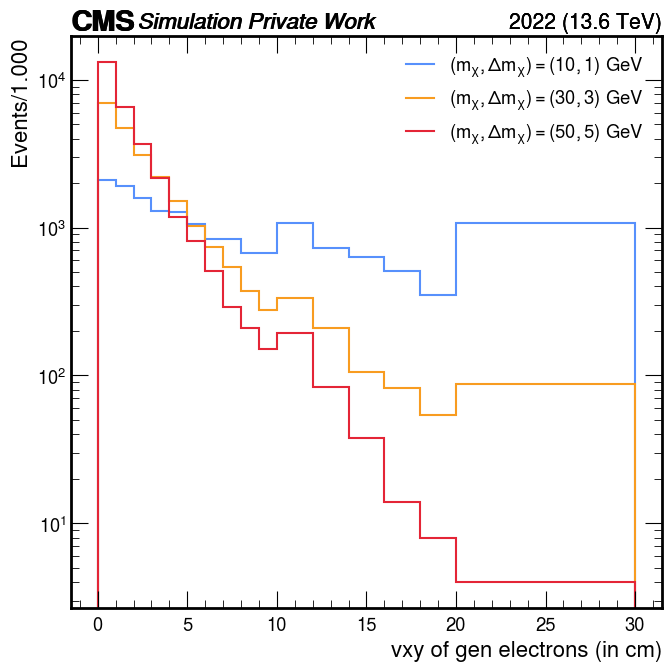

In [68]:
fig, ax = plt.subplots(figsize=(7,7))

delta =0.1
ctau =10

# Plot settings
plot_dict = {
    'variable':'gen_ele_vxy1',
    'cut': 'cut2',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': False, 
    'xlabel': "vxy of gen electrons (in cm)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'gen_ele_vxy10_m110.png'
}



#signal points
m1s=[10,30,50]
delta =0.1
ctau =10


results = [
    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
    
    for m1 in m1s
]

counts, edges = zip(*results)

counts = np.array(counts)     # shape: (n_m1, n_bins)
edges  = np.array(edges)      # shape: (n_m1, n_edges)

# counts, edges = ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)


mask = counts != 0

bins_x = (edges[:,:-1] + edges[:,1:])*(0.5)

counts_nonzero_den = np.where(mask, counts, np.nan)
edges_nonzero_den  = np.where(mask, bins_x, np.nan)


avg_den = np.mean(counts_nonzero_den, axis=0)
print("average=", avg_den)


# total = np.sum(counts_nonzero_den)
# print ("TOTAL number of gen electrons:", total)


Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
average= [1889.33333333 1003.33333333  592.66666667  388.33333333  268.66666667
  194.          129.33333333  105.           74.           75.
   84.66666667   43.66666667   26.66666667   18.           12.66666667
   30.33333333]
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
average= [3628.66666667 1930.33333333 1094.66666667  587.66666667  397.33333333
  283.33333333  174.66666667  119.           82.33333333   78.33333333
   88.66666667   44.66666667   28.           19.           12.66666667
   30.66666667]


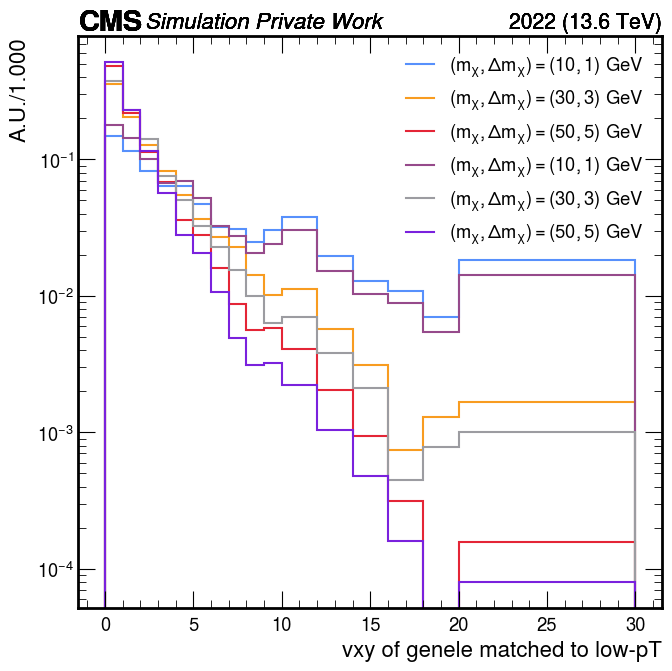

In [69]:
fig, ax = plt.subplots(figsize=(7,7))

plot_dict = {'variable': 'vxy_genElePos_Lpt', 'cut': 'cut2', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "vxy of genele matched to low-pT",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}

#signal points
m1s=[10,30,50]
delta =0.1
ctau =10


results_xcleaned = [
    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
    
    for m1 in m1s
]

counts_xcleaned, edges_xcleaned = zip(*results_xcleaned)

counts_xcleaned = np.array(counts_xcleaned)     # shape: (n_m1, n_bins)
edges_xcleaned  = np.array(edges_xcleaned)      # shape: (n_m1, n_edges)


bins_x_xcleaned = (edges_xcleaned[:,:-1] + edges_xcleaned[:,1:])*(0.5)



avg_num_Xcleanedcase = np.mean(counts_xcleaned, axis=0)
print("average=", avg_num_Xcleanedcase)

################################################################################################################################



plot_dict = {'variable': 'vxy_genElePos_Lpt_Noxclean', 'cut': 'cut2', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "vxy of genele matched to low-pT",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}


#signal points
m1s=[10,30,50]
delta =0.1
ctau =10


results_noxcleaned = [
    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
    
    for m1 in m1s
]

counts_noxcleaned, edges_noxcleaned = zip(*results_noxcleaned)

counts_noxcleaned = np.array(counts_noxcleaned)     # shape: (n_m1, n_bins)
edges_noxcleaned  = np.array(edges_noxcleaned)      # shape: (n_m1, n_edges)


bins_x_noxcleaned = (edges_noxcleaned[:,:-1] + edges_noxcleaned[:,1:])*(0.5)



avg_num_noXcleanedcase = np.mean(counts_noxcleaned, axis=0)
print("average=", avg_num_noXcleanedcase)

Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
average= [1.89133333e+03 1.00766667e+03 5.48333333e+02 2.20333333e+02
 1.38000000e+02 9.93333333e+01 5.26666667e+01 1.73333333e+01
 1.03333333e+01 4.66666667e+00 5.00000000e+00 2.33333333e+00
 1.33333333e+00 2.66666667e+00 6.66666667e-01 1.33333333e+00]


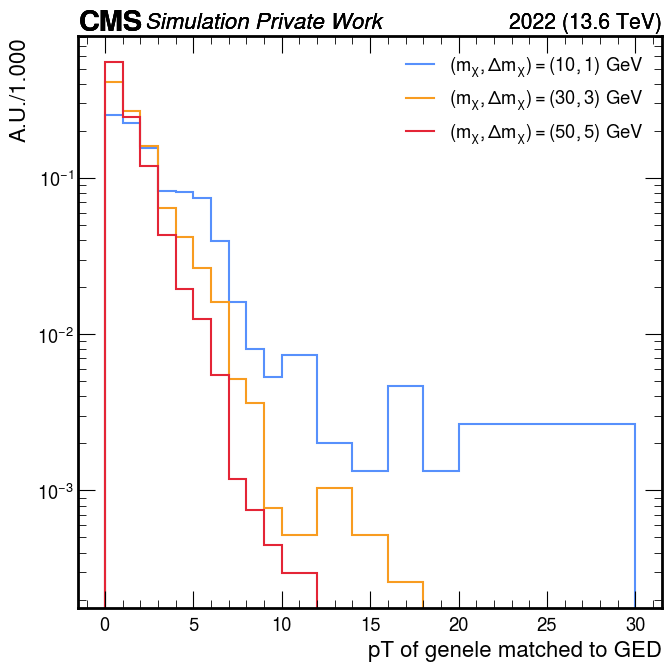

In [70]:
fig, ax = plt.subplots(figsize=(7,7))



plot_dict = {'variable': 'vxy_genElePos_GED', 'cut': 'cut2', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "pT of genele matched to GED",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}

#signal points
m1s=[10,30,50]
delta =0.1
ctau =10


results_GED = [
    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
    
    for m1 in m1s
]

counts_GED, edges_GED = zip(*results_GED)

counts_GED = np.array(counts_GED)     # shape: (n_m1, n_bins)
edges_GED  = np.array(edges_GED)      # shape: (n_m1, n_edges)


bins_x_GED = (edges_GED[:,:-1] + edges_GED[:,1:])*(0.5)



avg_num_GED = np.mean(counts_GED, axis=0)
print("average=", avg_num_GED)


In [71]:
def eff_determine_unc(n, d):
    eff = np.divide(n, d)
    unc = hist.intervals.ratio_uncertainty(n, d, 'efficiency')
    return eff, unc


efficiency_noxclean, unc_eff_noxclean = eff_determine_unc(avg_num_noXcleanedcase, avg_den)
print ("efficiency_noxclean:",efficiency_noxclean)

efficiency_xcleaned, unc_eff_xcleaned = eff_determine_unc(avg_num_Xcleanedcase, avg_den)
print ("efficiency_xcleaned:",efficiency_xcleaned)

efficiency_GED, unc_eff_GED = eff_determine_unc(avg_num_GED, avg_den)
print ("efficiency_GED:",efficiency_GED)

efficiency_noxclean: [0.49062556 0.43864566 0.3931051  0.31060606 0.29844767 0.29371113
 0.25216554 0.21428571 0.19728435 0.2124774  0.16542289 0.13085938
 0.10852713 0.09405941 0.09178744 0.07917384]
efficiency_xcleaned: [0.2554534  0.22799576 0.21283218 0.20525018 0.2018027  0.20110574
 0.186718   0.18907563 0.17731629 0.2034358  0.1579602  0.12792969
 0.10335917 0.08910891 0.09178744 0.07831325]
efficiency_GED: [0.25572381 0.22898046 0.19691166 0.11645525 0.10365548 0.10297167
 0.07603465 0.03121248 0.02476038 0.01265823 0.00932836 0.00683594
 0.00516796 0.01320132 0.00483092 0.00344234]


In [72]:
#Total Eff

#Numerator = number of gen matched to GED + number of gen matched to lpt (xcleaned case)
Numerator = avg_num_GED + avg_num_Xcleanedcase

eff_total_rec, unc_eff_rec = eff_determine_unc(Numerator, avg_den)
print ("Total Eff=", eff_total_rec)

Total Eff= [0.51117721 0.45697622 0.40974384 0.32170543 0.30545819 0.3040774
 0.26275265 0.22028812 0.20207668 0.21609403 0.16728856 0.13476562
 0.10852713 0.10231023 0.09661836 0.08175559]


In [73]:
print ("bins_x_noxcleaned[0,:]=", bins_x_noxcleaned[0,:])
print ("bins_x_xcleaned=", bins_x_xcleaned)
print ("bins_x_GED=", bins_x_GED)

bins_x_noxcleaned[0,:]= [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 11.  13.  15.  17.
 19.  25. ]
bins_x_xcleaned= [[ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 11.  13.  15.  17.
  19.  25. ]
 [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 11.  13.  15.  17.
  19.  25. ]
 [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 11.  13.  15.  17.
  19.  25. ]]
bins_x_GED= [[ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 11.  13.  15.  17.
  19.  25. ]
 [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 11.  13.  15.  17.
  19.  25. ]
 [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 11.  13.  15.  17.
  19.  25. ]]


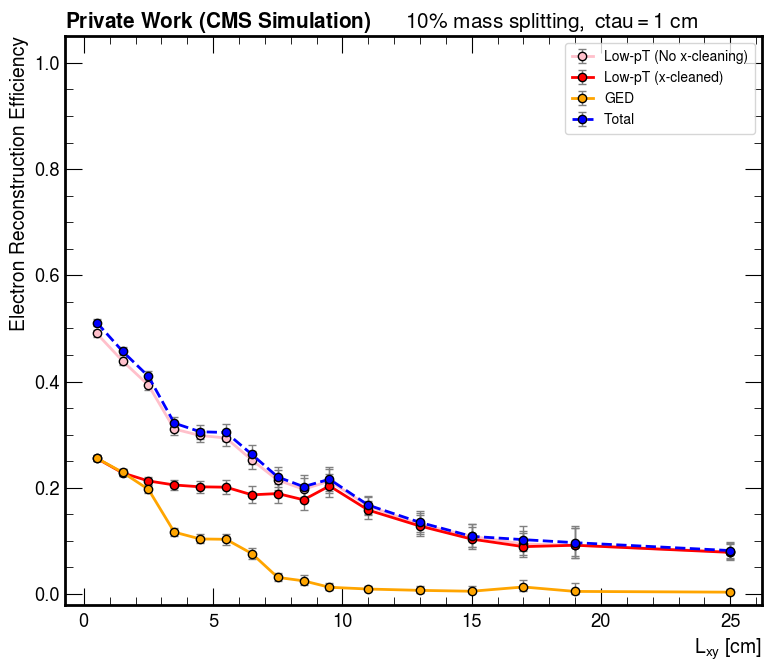

In [74]:
plt.figure(figsize=(8,7))

plt.errorbar(
    bins_x_noxcleaned[0,:],
    efficiency_noxclean,
    yerr=unc_eff_noxclean,
    fmt='o-',
    linewidth=2,
    markersize=6,
    color='pink',
    markeredgecolor='black',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label='Low-pT (No x-cleaning)'
)

plt.errorbar(
    bins_x_xcleaned[0,:],
    efficiency_xcleaned,
    yerr=unc_eff_xcleaned,
    fmt='o-',
    linewidth=2,
    markersize=6,
    color='red',
    markeredgecolor='black',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label='Low-pT (x-cleaned)'
)

plt.errorbar(
    bins_x_GED[0,:],
    efficiency_GED,
    yerr=unc_eff_GED,
    fmt='o-',
    linewidth=2,
    markersize=6,
    color='orange',
    markeredgecolor='black',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label='GED'
)


plt.errorbar(
    bins_x_GED[0,:],
    eff_total_rec,
    yerr=unc_eff_rec,
    fmt='o--',
    linewidth=2,
    markersize=6,
    color='blue',
    markeredgecolor='black',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label='Total'
)

# Axis styling
plt.ylim(-0.02, 1.05)
plt.xlabel(r"$L_{xy}$ [cm]", fontsize=14)
plt.ylabel("Electron Reconstruction Efficiency", fontsize=14)



# Grid helps readability
# plt.grid(True, linestyle='--', alpha=0.4)

# Better title formatting


# plt.title(
    
#     r"$10\%\ \mathrm{mass\ splitting},\ c\tau = 10\ \mathrm{mm}$",
#     fontsize=18
# )

plt.title(r"$\bf{Private\ Work\ (CMS\ Simulation)} \qquad \mathrm{10\% \ mass\ splitting,\ ctau = 1\ cm}$",
          fontsize=15, loc='left')

plt.legend(fontsize=10, frameon=True, loc='upper right')

plt.tight_layout()

plt.savefig("L_lxy_ERE.png", dpi=300)